# This is just for fun


# Ran correctly 25-05-2026 in the morning.

In [249]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import geodatasets
from matplotlib.colors import Normalize
import matplotlib as mpl

In [190]:
df = pd.read_csv(r"C:/Users\ulrik\OneDrive - University of Copenhagen\År4\Applied Machine Learning\final_project\git_hub_final_project\scrandle_ml_project\data\grand_scraper_folder\unique_scrandle_cases_FULL.csv")

#df.head()

beer_df = df[
    df["title"].str.contains("beer", case=False, na=False) |
    df["subtitle"].str.contains("beer", case=False, na=False)
] #Whilke har oel?

# Convert country column into list (important!)
df["country_list"] = df["country"].fillna("").apply(lambda x: x.split(" | "))


In [191]:
titles = df["title"].tolist()
subtitles = df["subtitle"].tolist()
prices = df["price"].tolist()
ratings = df["rating"].tolist()
hashes = df["image_hash"].tolist()
occurrences = df["occurrences"].tolist()


In [192]:
# Count occurrences per row
df["n_appear"] = df["occurrences"].apply(lambda x: len(x.split(" | ")))
print(df["n_appear"])

0       7
1       1
2       6
3       4
4       5
       ..
4583    1
4584    1
4585    1
4586    1
4587    1
Name: n_appear, Length: 4588, dtype: int64


In [193]:
n_beer = len(beer_df)
n_total = len(df)

print(f"Beer cases: {n_beer}")
print(f"Total cases: {n_total}")


mean_beer = beer_df["rating"].mean()
mean_all = df["rating"].mean()

print(f"Average rating (beer): {mean_beer:.2f}")
print(f"Average rating (all):  {mean_all:.2f}")

Beer cases: 102
Total cases: 4588
Average rating (beer): 53.74
Average rating (all):  52.85


In [194]:
std_beer = beer_df["rating"].std()
std_all = df["rating"].std()

print(f"Std (beer): {std_beer:.2f}")
print(f"Std (all):  {std_all:.2f}")


Std (beer): 23.73
Std (all):  26.09


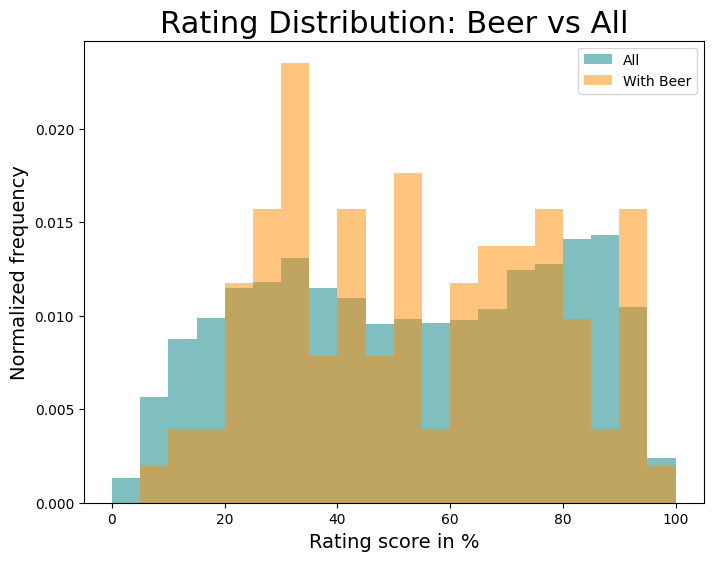

In [195]:
bins = np.arange(0, 105, 5)



plt.figure(figsize = (8,6))
plt.hist(df["rating"], bins=bins, alpha=0.5, label="All", density = True, color = "teal")
plt.hist(beer_df["rating"], bins=bins, alpha=0.5, label="With Beer" , density  = True, color = "darkorange")

plt.legend()
plt.xlabel("Rating score in %", fontsize = 14 )
plt.ylabel("Normalized frequency", fontsize = 14)
plt.title("Rating Distribution: Beer vs All", fontsize = 22)
plt.show()


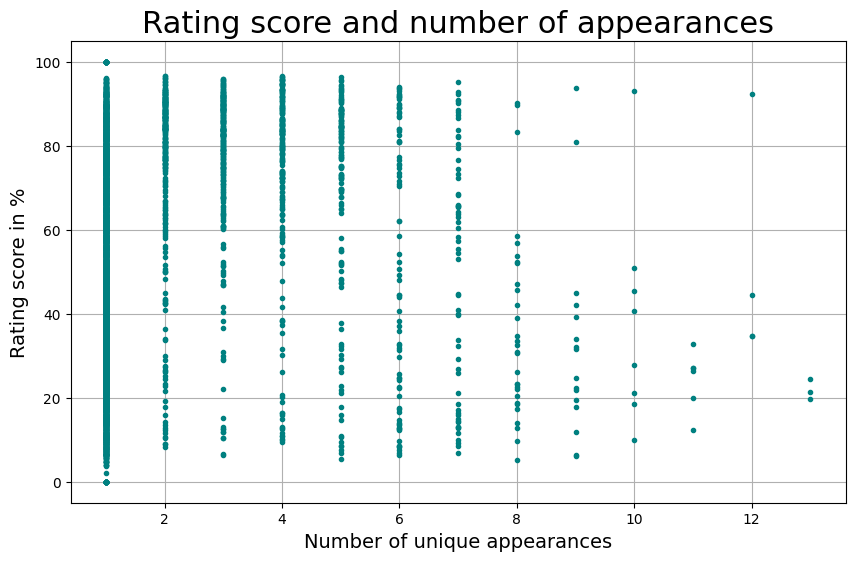

In [196]:
plt.figure(figsize = (10,6))

plt.plot(df["n_appear"], df["rating"], '.',color = 'teal')

plt.xlabel('Number of unique appearances', fontsize  = 14)
plt.ylabel('Rating score in %', fontsize = 14)
plt.title('Rating score and number of appearances', fontsize = 22)
plt.grid()
plt.show()





In [197]:
mask = df["price"].notna()
print(mask)

Jakobs_rate = df['rating'][mask]
Jakobs_price = df['price'][mask]
Jakobs_price

0       True
1       True
2       True
3       True
4       True
        ... 
4583    True
4584    True
4585    True
4586    True
4587    True
Name: price, Length: 4588, dtype: bool


0        2.60
1        9.50
2        2.80
3        3.40
4        5.50
        ...  
4583     5.20
4584     3.40
4585     5.50
4586    16.45
4587     7.95
Name: price, Length: 4250, dtype: float64

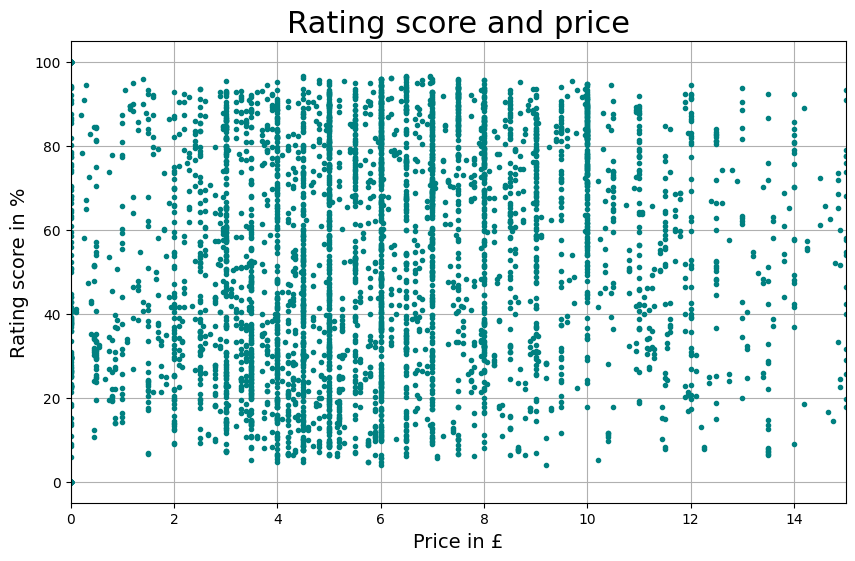

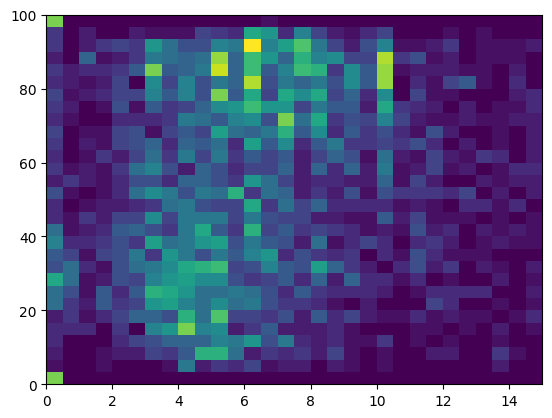

In [198]:
plt.figure(figsize = (10,6))

plt.plot( df["price"], df["rating"], '.',color = 'teal')

plt.xlabel('Price in £', fontsize  = 14)
plt.ylabel('Rating score in %', fontsize = 14)
plt.title('Rating score and price', fontsize = 22)
plt.grid()
plt.xlim([0,15])
plt.show()

plt.hist2d(Jakobs_price, Jakobs_rate, bins  =30, range  = [[0,15],[0,100]])
plt.xlim([0,15])
plt.show()

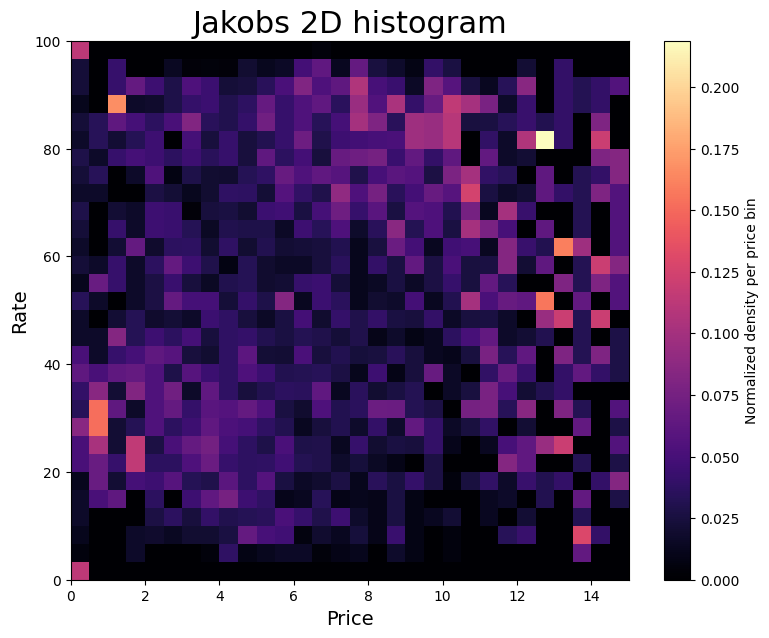

In [199]:
# Compute 2D histogram
H, xedges, yedges = np.histogram2d(
    Jakobs_price, Jakobs_rate,
    bins=30,
    range=[[0, 15], [0, 100]]
)

# Normalize each column (along y-axis)
H_norm = H / H.sum(axis=1, keepdims=True)  # normalize per price bin

# Avoid division by zero
H_norm = np.nan_to_num(H_norm)

# Plot
plt.figure(figsize = (9,7))
plt.pcolormesh(xedges, yedges, H_norm.T, shading='auto', cmap = 'magma')
plt.colorbar(label='Normalized density per price bin')
plt.title('Jakobs 2D histogram', fontsize = 22)
plt.xlabel('Price', fontsize = 14)
plt.ylabel('Rate', fontsize = 14)
plt.show()

# Herefrom follows country analyses.

In [200]:
# Explode countries into separate rows
df_country = df.explode("country_list")

# Remove empty ones
df_country = df_country[df_country["country_list"] != ""]

# Group stats
country_stats = df_country.groupby("country_list")["rating"].agg(["mean", "std", "count"])

# Optional: filter only countries with enough data
country_stats = country_stats[country_stats["count"] >= 5]

# Sort
country_stats = country_stats.sort_values("mean", ascending=False)

print(country_stats.head())

                   mean        std  count
country_list                             
KOR           81.595882  14.500521     17
COL           70.650000  17.962016      7
BEL           65.465385  25.375295     13
THA           64.092000  27.877843     15
SWE           63.300000  22.240879     12


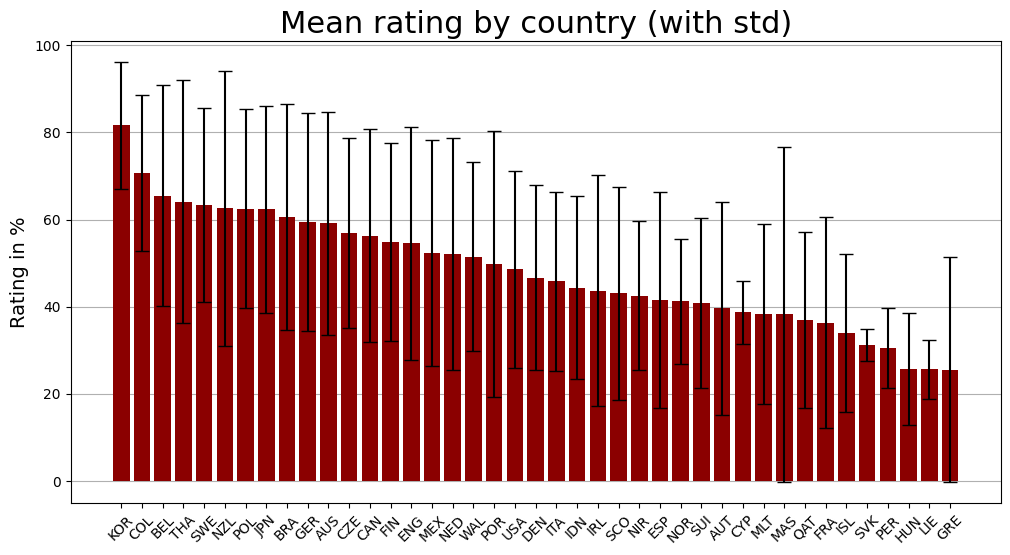

In [201]:
plt.figure(figsize=(12,6))

plt.bar(country_stats.index, country_stats["mean"], yerr=country_stats["std"], color = 'darkred', capsize=5, zorder = 3)

plt.xticks(rotation=45)
plt.ylabel("Rating in %", fontsize = 14)
plt.title("Mean rating by country (with std)", fontsize = 22)
plt.grid(axis='y')

plt.show()


In [228]:
df_plot = country_stats.reset_index()
df_plot = df_plot.rename(columns={"country_list": "ADM0_A3"})
df_plot["ADM0_A3"] = df_plot["ADM0_A3"].replace({
    "ENG": "GBR",
    "SCO": "GBR",
    "GER": "DEU",
    "DEN": "DNK",
    "NED": "NLD",
    "POR": "PRT",
    "GRE": "GRC"
})
df_plot = df_plot.groupby("ADM0_A3", as_index=False)["mean"].mean()
# ----------------------------
# 2. Load map
# ----------------------------
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_countries.zip"
)

europe = world.merge(
    df_plot,
    on="ADM0_A3",
    how="left"
)



In [244]:
# Remove huge countries
exclude = ["Russia", "Kazakhstan"]
exclude = ["Japan", "South Korea", "Colombia"]
europe_zoom = europe[~europe["NAME"].isin(exclude)]


visible = europe_zoom.dropna(subset=["mean"])

norm = Normalize(
    vmin=visible["mean"].min(),
    vmax=visible["mean"].max()
)

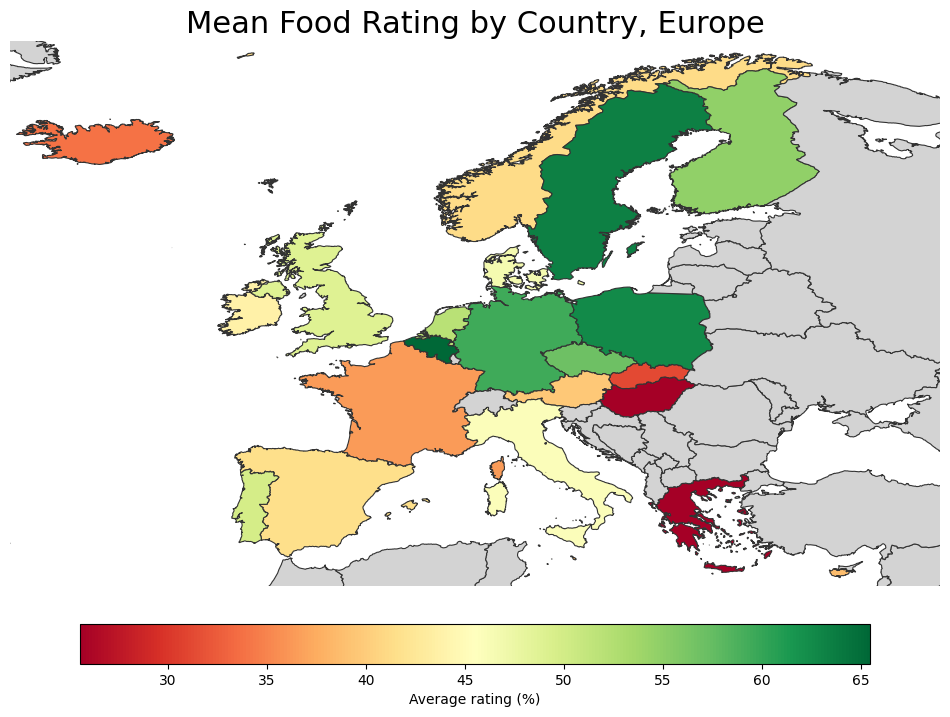

United Kingdom  = average of Scotland and England's cases


In [246]:
fig, ax = plt.subplots(figsize=(12,10))

# Plot
europe_zoom.plot(
    ax=ax,
    column="mean",
    #cmap="YlGnBu",
    cmap="RdYlGn",
    norm=norm,   # ✅ THIS is the real fix
    linewidth=0.8,
    edgecolor="#333333",
    legend=True,
    missing_kwds={"color": "lightgrey"},
    legend_kwds={
        "label": "Average rating (%)",
        "orientation": "horizontal",
        "shrink": 0.85,
        "pad": 0.05
    }
)


# Remove extra whitespace
ax.set_xlim([-25, 40])
ax.set_ylim([34, 72])

ax.set_title("Mean Food Rating by Country, Europe", fontsize=22)
ax.axis("off")

plt.show()
print("United Kingdom  = average of Scotland and England's cases")



In [247]:
asia_codes = ["JPN", "KOR"]

asia = world[world["ADM0_A3"].isin(asia_codes)]

# merge values
asia = asia.merge(df_plot, on="ADM0_A3", how="left")


In [253]:
# Combine only relevant values
combined = pd.concat([
    europe_zoom[["mean"]],
    asia[["mean"]]
])

visible = combined.dropna()

norm = Normalize(
    vmin=visible["mean"].min(),
    vmax=visible["mean"].max()
)


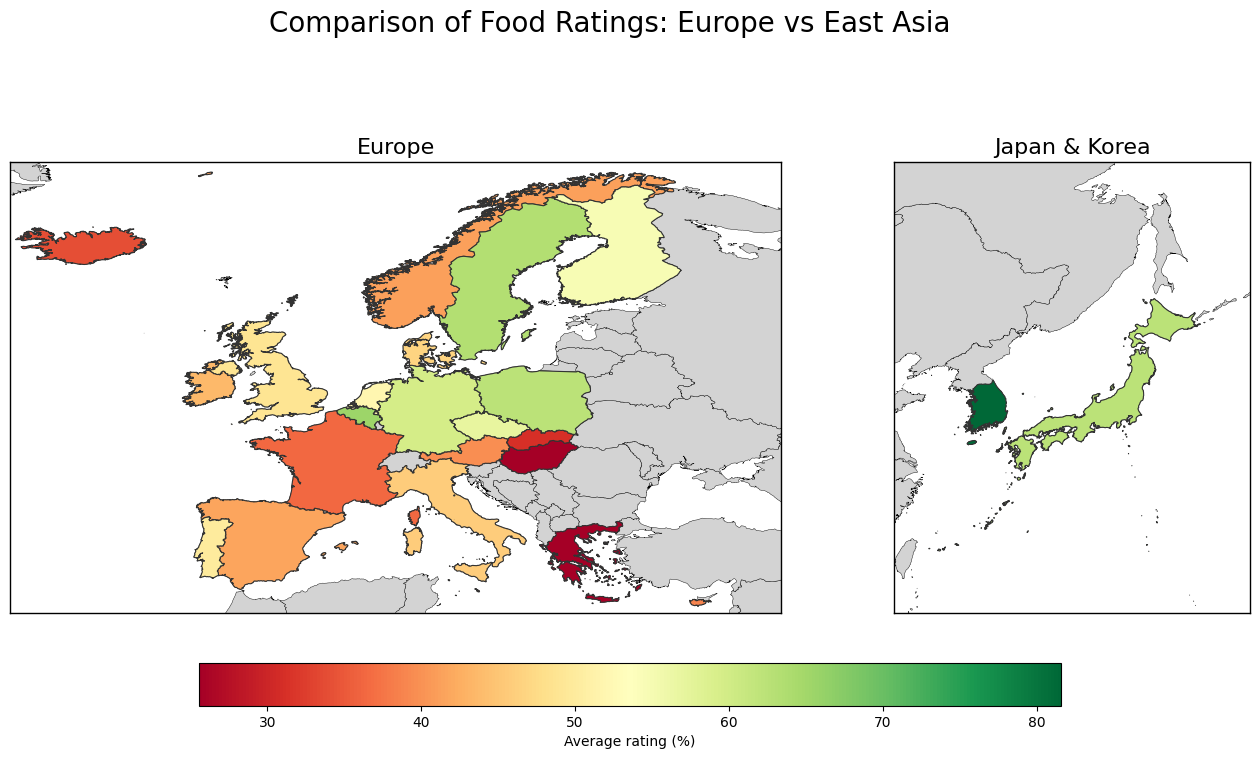

In [268]:
# --- bounds ---
xmin_eu, xmax_eu = -25, 40
xmin_as, xmax_as = 120, 150

# Europe vertical span
ymin_eu, ymax_eu = 34, 72
height = ymax_eu - ymin_eu  # ✅ shared height

# --- center Asia properly ---
# pick center for Japan/Korea
y_center_as = 38  

ymin_as = y_center_as - height / 2
ymax_as = y_center_as + height / 2


# --- widths (same as before) ---
width_eu = xmax_eu - xmin_eu
width_as = xmax_as - xmin_as


# --- figure ---
fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 8),
    gridspec_kw={"width_ratios": [width_eu, width_as]}
)

ax1, ax2 = axes


# -------- EUROPE --------
world.plot(ax=ax1, color="lightgrey", edgecolor="black", linewidth=0.3)

europe_zoom.plot(
    ax=ax1,
    column="mean",
    cmap="RdYlGn",
    norm=norm,
    linewidth=0.8,
    edgecolor="#333333"
)

ax1.set_xlim([xmin_eu, xmax_eu])
ax1.set_ylim([ymin_eu, ymax_eu])
ax1.set_title("Europe", fontsize=16)
ax1.set_aspect("equal")
for ax in [ax1, ax2]:
    ax.set_xticks([])
    ax.set_yticks([])

    # ✅ turn on frame
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)   # adjust thickness
        spine.set_color("black")



# -------- ASIA --------
world.plot(ax=ax2, color="lightgrey", edgecolor="black", linewidth=0.3)

asia.plot(
    ax=ax2,
    column="mean",
    cmap="RdYlGn",
    norm=norm,
    linewidth=0.8,
    edgecolor="#333333"
)

ax2.set_xlim([xmin_as, xmax_as])

# ✅ KEY LINE (this fixes your issue)
ax2.set_ylim([ymin_as, ymax_as])

ax2.set_title("Japan & Korea", fontsize=16)
ax2.set_aspect("equal")


sm = mpl.cm.ScalarMappable(cmap="RdYlGn", norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    orientation="horizontal",
    fraction=0.07,
    pad=0.08
)

cbar.set_label("Average rating (%)")


# -------- TITLE --------
fig.suptitle(
    "Comparison of Food Ratings: Europe vs East Asia",
    fontsize=20
)

plt.show()

# Compare types of foods.

In [280]:
keywords = {
    "Burger": r"burger",
    "Hotdog": r"\bhot\s*dog\b",
    "Sandwich": r"sandwich",
    "Pie": r"pie",
    "Sausage": r"sausage",
    "Cheese": r"\b(cheese|cheesy)\b",
    "Mash": r"mash",
    "Doughnut": r"\b(donut|doughnut)\b",
    "Poutine": r"poutine",
    "Fries": r"\b(fry|fries)\b",   # fry + fries
    "Soda": r"soda",
    "Beer": r"\b(beer|ipa|lager|ale|stout|seltzer)\b",  # broader beer types
    "Waffle": r"waffle",
    "Sushi": r"sushi"
}



def keyword_stats_regex(df, keywords):
    results = {}

    for name, pattern in keywords.items():
        mask = (
            df["title"].str.contains(pattern, case=False, na=False, regex=True) |
            df["subtitle"].str.contains(pattern, case=False, na=False, regex=True)
        )

        subset = df[mask]

        results[name] = {
            "mean": subset["rating"].mean(),
            "std": subset["rating"].std(),
            "count": len(subset)
        }

    return pd.DataFrame(results).T

kw_stats = keyword_stats_regex(df, keywords)


C:\Users\ulrik\AppData\Local\Temp\ipykernel_5688\3220130149.py:25: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["title"].str.contains(pattern, case=False, na=False, regex=True) |
C:\Users\ulrik\AppData\Local\Temp\ipykernel_5688\3220130149.py:26: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["subtitle"].str.contains(pattern, case=False, na=False, regex=True)


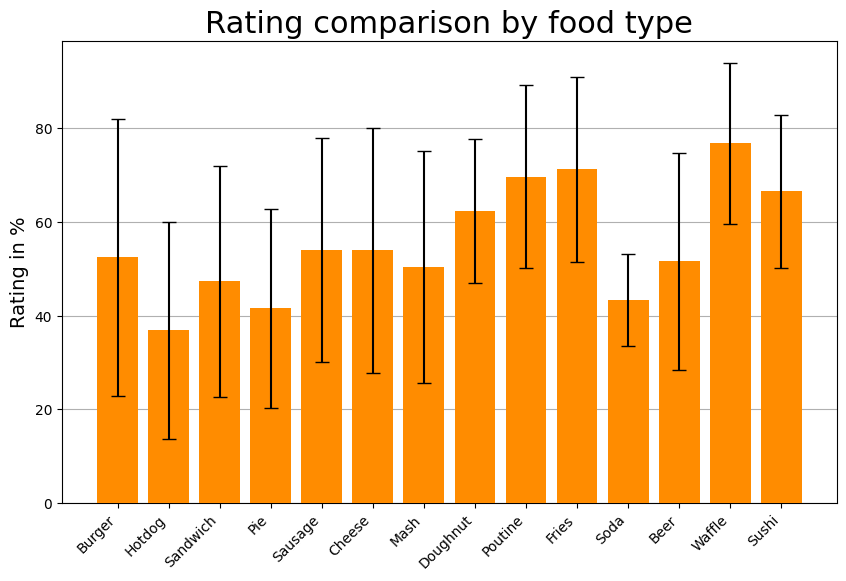

In [281]:
plt.figure(figsize=(10,6))

plt.bar(kw_stats.index, kw_stats["mean"], yerr=kw_stats["std"], color = "darkorange", capsize=5, zorder = 3)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Rating in %", fontsize = 14)
plt.title("Rating comparison by food type", fontsize = 22)
plt.grid(axis='y')

plt.show()


In [208]:
# Tryn restnet later.

